# 🔬 Análise Comparativa de Modelos Mixture of Experts (MoE)
## Detecção de Manipulação de Imagens: MoE Standard vs. MoE Frequency
**Autor:** Lucas Cunha  
**Contexto:** Trabalho de Conclusão de Curso (TCC) / Artigo ICLR  
**Data:** Setembro de 2026  

---
### 📌 Visão Geral do Experimento
Este notebook consolida e analisa detalhadamente o desempenho empírico de duas variantes da arquitetura **Mixture of Experts (MoE)** propostas para detecção de manipulação de imagens forenses:
1. **MoE Standard (Spatial RGB)**: Quatro especialistas MobileNet-Small operando cooperativamente no domínio espacial RGB convencional (3 canais).
2. **MoE Frequency (Spatial + Fourier 2D-FFT)**: Quatro especialistas MobileNet-Small desacoplados e especializados em domínios específicos (Espacial RGB, Magnitude espectral log-comprimida, Fase espectral e Filtro Passa-Alta de alta frequência).

Ambos os modelos foram treinados do zero (*scratch*, `seed=42`, batch size 16) no dataset de grande escala (~524.430 imagens de treino, ~147.364 de validação e ~181.947 de teste).


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configurações de estilo
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

REPO_ROOT = Path("..").resolve() if Path("..").resolve().name == "TCC" else Path(".").resolve()
MODELS_ROOT = REPO_ROOT / "models"
ARCHIVE_ROOT = MODELS_ROOT / "archive_4experts"

print(f"Diretório do repositório: {REPO_ROOT}")


Diretório do repositório: /home/lucas/projetos/TCC


## 1. Carregamento Automatizado dos Dados e Históricos de Treino


In [2]:
def load_model_data(model_name, fourier_mode):
    paths_to_try = [
        MODELS_ROOT / model_name / fourier_mode / "scratch" / "seed_42" / "results",
        ARCHIVE_ROOT / model_name / fourier_mode / "scratch" / "seed_42" / "results"
    ]
    res_dir = next((p for p in paths_to_try if p.exists()), None)
    if not res_dir:
        raise FileNotFoundError(f"Resultados não encontrados para {model_name}/{fourier_mode}")
    
    summary = pd.read_csv(res_dir / "metrics_summary.csv")
    test_metrics = pd.read_csv(res_dir / "metrics_test.csv")
    val_metrics = pd.read_csv(res_dir / "metrics_val.csv")
    history = pd.read_csv(res_dir / "history.csv")
    
    return {
        "summary": summary,
        "test": test_metrics,
        "val": val_metrics,
        "history": history,
        "dir": res_dir
    }

std_data = load_model_data("moe_standard", "none")
freq_data = load_model_data("moe_frequency", "concat_frequency")

print(f"[✓] MoE Standard carregado ({len(std_data['history'])} épocas)")
print(f"[✓] MoE Frequency carregado ({len(freq_data['history'])} épocas - Early Stopping)")


[✓] MoE Standard carregado (20 épocas)
[✓] MoE Frequency carregado (18 épocas - Early Stopping)


## 2. Tabela Comparativa de Métricas (Conjunto de Teste: 181.947 Amostras)


In [3]:
test_comparison = pd.DataFrame([
    {
        "Modelo": "MoE Standard",
        "Domínio": "RGB Espacial (3 ch)",
        "Acurácia (%)": std_data["test"]["acc"].iloc[0] * 100,
        "ROC-AUC": std_data["test"]["auc"].iloc[0],
        "F1-Score (%)": std_data["test"]["f1"].iloc[0] * 100,
        "Precisão (%)": std_data["test"]["precision"].iloc[0] * 100,
        "Recall (%)": std_data["test"]["recall"].iloc[0] * 100,
        "Especificidade (%)": std_data["test"]["specificity"].iloc[0] * 100,
        "Loss Teste": std_data["test"]["loss"].iloc[0],
        "Threshold": std_data["test"]["threshold"].iloc[0],
    },
    {
        "Modelo": "MoE Frequency",
        "Domínio": "RGB + FFT (6 ch)",
        "Acurácia (%)": freq_data["test"]["acc"].iloc[0] * 100,
        "ROC-AUC": freq_data["test"]["auc"].iloc[0],
        "F1-Score (%)": freq_data["test"]["f1"].iloc[0] * 100,
        "Precisão (%)": freq_data["test"]["precision"].iloc[0] * 100,
        "Recall (%)": freq_data["test"]["recall"].iloc[0] * 100,
        "Especificidade (%)": freq_data["test"]["specificity"].iloc[0] * 100,
        "Loss Teste": freq_data["test"]["loss"].iloc[0],
        "Threshold": freq_data["test"]["threshold"].iloc[0],
    }
])

delta = {
    "Modelo": "Δ (Frequency - Standard)",
    "Domínio": "-",
    "Acurácia (%)": test_comparison["Acurácia (%)"].iloc[1] - test_comparison["Acurácia (%)"].iloc[0],
    "ROC-AUC": test_comparison["ROC-AUC"].iloc[1] - test_comparison["ROC-AUC"].iloc[0],
    "F1-Score (%)": test_comparison["F1-Score (%)"].iloc[1] - test_comparison["F1-Score (%)"].iloc[0],
    "Precisão (%)": test_comparison["Precisão (%)"].iloc[1] - test_comparison["Precisão (%)"].iloc[0],
    "Recall (%)": test_comparison["Recall (%)"].iloc[1] - test_comparison["Recall (%)"].iloc[0],
    "Especificidade (%)": test_comparison["Especificidade (%)"].iloc[1] - test_comparison["Especificidade (%)"].iloc[0],
    "Loss Teste": test_comparison["Loss Teste"].iloc[1] - test_comparison["Loss Teste"].iloc[0],
    "Threshold": freq_data["test"]["threshold"].iloc[0] - std_data["test"]["threshold"].iloc[0],
}
df_full_tab = pd.concat([test_comparison, pd.DataFrame([delta])], ignore_index=True)
display(df_full_tab.round(4))


,Modelo,Domínio,Acurácia (%),ROC-AUC,F1-Score (%),Precisão (%),Recall (%),Especificidade (%),Loss Teste,Threshold
0,MoE Standard,RGB Espacial (3 ch),77.8765,0.8831,77.7464,91.8694,67.3870,91.9809,1.1791,0.9774
1,MoE Frequency,RGB + FFT (6 ch),78.6806,0.8737,79.6883,87.8366,72.9235,86.4217,1.7828,0.9885
2,Δ (Frequency - Standard),-,0.8041,-0.0094,1.9419,-4.0328,5.5364,-5.5591,0.6037,0.0111


## 3. Visualizações Comparativas no Conjunto de Teste


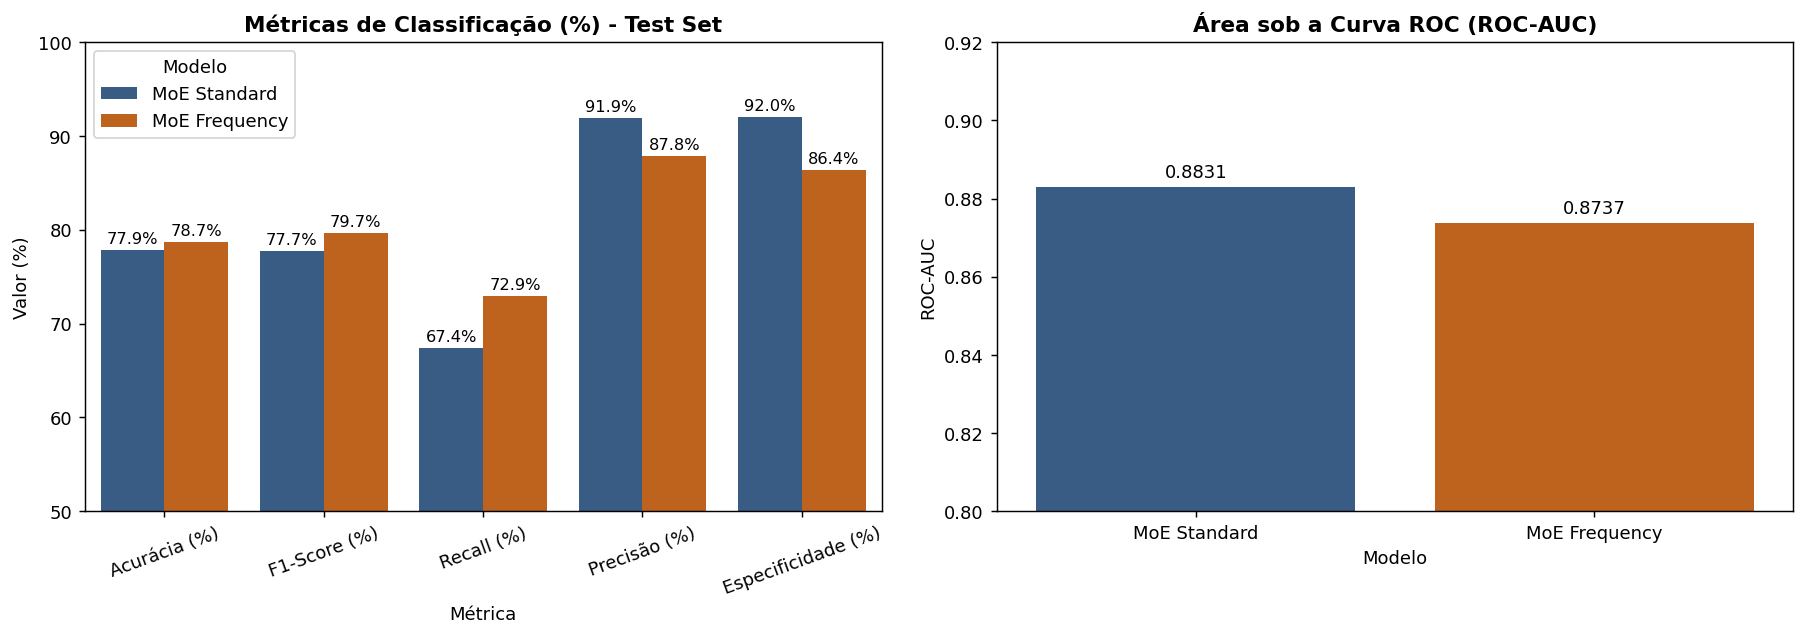

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_plot_pct = test_comparison.iloc[:2][["Modelo", "Acurácia (%)", "F1-Score (%)", "Recall (%)", "Precisão (%)", "Especificidade (%)"]]
df_plot_pct_melted = df_plot_pct.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor (%)")

sns.barplot(data=df_plot_pct_melted, x="Métrica", y="Valor (%)", hue="Modelo", palette=["#2b5c8f", "#d95f02"], ax=axes[0])
axes[0].set_title("Métricas de Classificação (%) - Test Set", fontweight="bold")
axes[0].set_ylim(50, 100)
axes[0].tick_params(axis='x', rotation=20)
for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h),
                         ha='center', va='bottom', fontsize=9, xytext=(0, 2), textcoords='offset points')

auc_vals = test_comparison.iloc[:2][["Modelo", "ROC-AUC"]]
sns.barplot(data=auc_vals, x="Modelo", y="ROC-AUC", palette=["#2b5c8f", "#d95f02"], ax=axes[1])
axes[1].set_title("Área sob a Curva ROC (ROC-AUC)", fontweight="bold")
axes[1].set_ylim(0.80, 0.92)
for p in axes[1].patches:
    h = p.get_height()
    axes[1].annotate(f"{h:.4f}", (p.get_x() + p.get_width() / 2., h),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


## 4. Dinâmica de Treinamento e Curvas de Aprendizado
Análise comparativa da convergência ao longo das épocas:
- **MoE Standard**: Treinou as 20 épocas programadas, atingindo seu ápice de validação na Época 20.
- **MoE Frequency**: Convergiu muito mais rápido, alcançando seu pico de validação logo na **Época 10** (Val AUC de **0.9496**), acionando o **Early Stopping** na época 18.


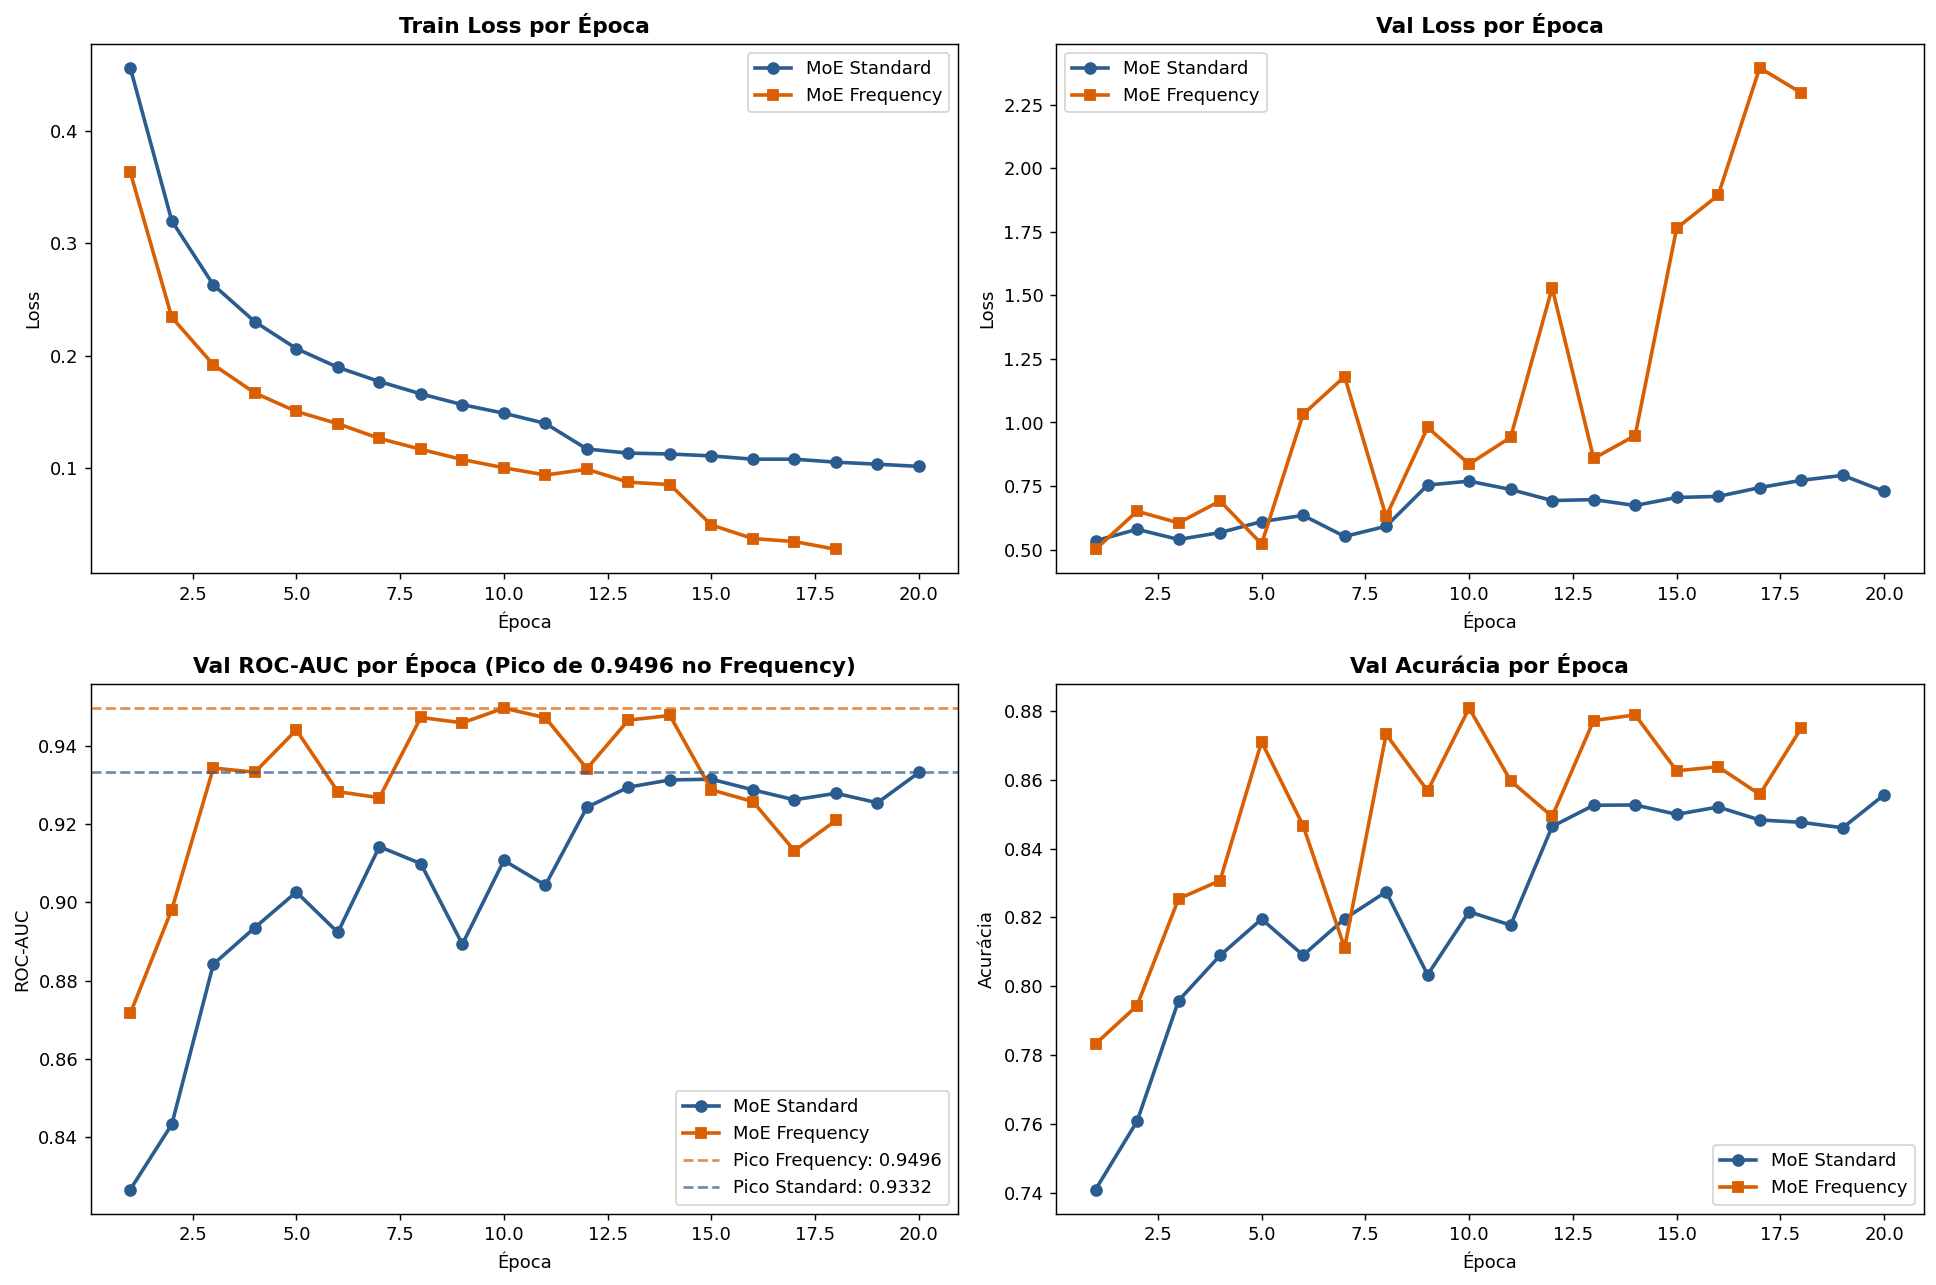

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
hist_std = std_data["history"]
hist_freq = freq_data["history"]

axes[0, 0].plot(hist_std["epoch"], hist_std["train_loss"], label="MoE Standard", marker="o", color="#2b5c8f", linewidth=2)
axes[0, 0].plot(hist_freq["epoch"], hist_freq["train_loss"], label="MoE Frequency", marker="s", color="#d95f02", linewidth=2)
axes[0, 0].set_title("Train Loss por Época", fontweight="bold")
axes[0, 0].set_xlabel("Época")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

axes[0, 1].plot(hist_std["epoch"], hist_std["val_loss"], label="MoE Standard", marker="o", color="#2b5c8f", linewidth=2)
axes[0, 1].plot(hist_freq["epoch"], hist_freq["val_loss"], label="MoE Frequency", marker="s", color="#d95f02", linewidth=2)
axes[0, 1].set_title("Val Loss por Época", fontweight="bold")
axes[0, 1].set_xlabel("Época")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()

axes[1, 0].plot(hist_std["epoch"], hist_std["val_auc"], label="MoE Standard", marker="o", color="#2b5c8f", linewidth=2)
axes[1, 0].plot(hist_freq["epoch"], hist_freq["val_auc"], label="MoE Frequency", marker="s", color="#d95f02", linewidth=2)
axes[1, 0].axhline(y=hist_freq["val_auc"].max(), color="#d95f02", linestyle="--", alpha=0.7, label=f"Pico Frequency: {hist_freq['val_auc'].max():.4f}")
axes[1, 0].axhline(y=hist_std["val_auc"].max(), color="#2b5c8f", linestyle="--", alpha=0.7, label=f"Pico Standard: {hist_std['val_auc'].max():.4f}")
axes[1, 0].set_title("Val ROC-AUC por Época (Pico de 0.9496 no Frequency)", fontweight="bold")
axes[1, 0].set_xlabel("Época")
axes[1, 0].set_ylabel("ROC-AUC")
axes[1, 0].legend()

axes[1, 1].plot(hist_std["epoch"], hist_std["val_acc"], label="MoE Standard", marker="o", color="#2b5c8f", linewidth=2)
axes[1, 1].plot(hist_freq["epoch"], hist_freq["val_acc"], label="MoE Frequency", marker="s", color="#d95f02", linewidth=2)
axes[1, 1].set_title("Val Acurácia por Época", fontweight="bold")
axes[1, 1].set_xlabel("Época")
axes[1, 1].set_ylabel("Acurácia")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## 5. Matrizes de Confusão e Diagnóstico de Erros Forenses
A análise da matriz de confusão no teste revela um trade-off operacional fundamental:
- O **MoE Frequency** acerta **76.092** imagens manipuladas contra **70.315** do MoE Standard (**+5.777 detecções forenses bem-sucedidas**).
- O **MoE Standard** apresenta menor número de falsos positivos (6.223 vs 10.537), sendo mais conservador.


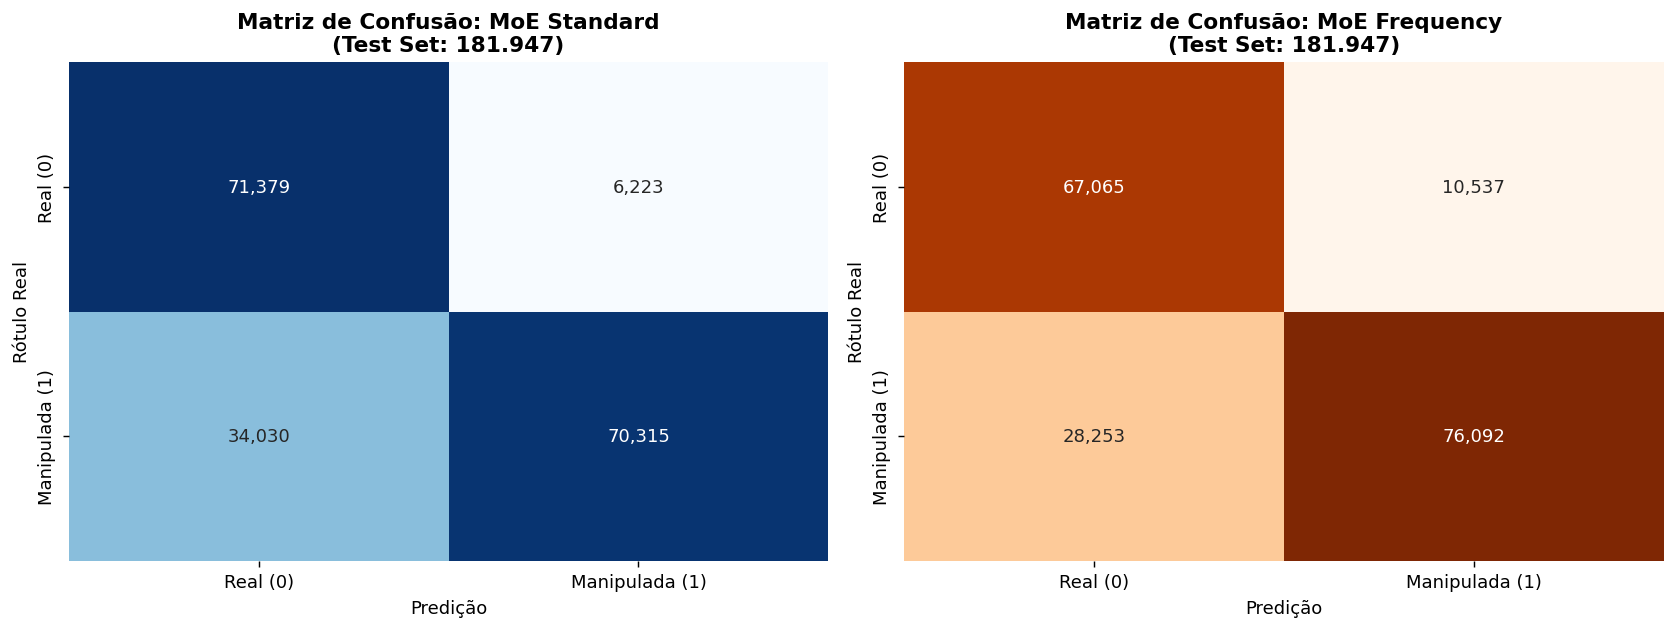

In [6]:
cm_std = np.array([
    [std_data["test"]["tn"].iloc[0], std_data["test"]["fp"].iloc[0]],
    [std_data["test"]["fn"].iloc[0], std_data["test"]["tp"].iloc[0]]
])

cm_freq = np.array([
    [freq_data["test"]["tn"].iloc[0], freq_data["test"]["fp"].iloc[0]],
    [freq_data["test"]["fn"].iloc[0], freq_data["test"]["tp"].iloc[0]]
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm_std, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Real (0)", "Manipulada (1)"], yticklabels=["Real (0)", "Manipulada (1)"])
axes[0].set_title("Matriz de Confusão: MoE Standard\n(Test Set: 181.947)", fontweight="bold")
axes[0].set_xlabel("Predição")
axes[0].set_ylabel("Rótulo Real")

sns.heatmap(cm_freq, annot=True, fmt=",d", cmap="Oranges", cbar=False, ax=axes[1],
            xticklabels=["Real (0)", "Manipulada (1)"], yticklabels=["Real (0)", "Manipulada (1)"])
axes[1].set_title("Matriz de Confusão: MoE Frequency\n(Test Set: 181.947)", fontweight="bold")
axes[1].set_xlabel("Predição")
axes[1].set_ylabel("Rótulo Real")

plt.tight_layout()
plt.show()


In [7]:
error_df = pd.DataFrame([
    {
        "Modelo": "MoE Standard",
        "Verdadeiros Positivos (TP)": int(std_data["test"]["tp"].iloc[0]),
        "Falsos Positivos (FP)": int(std_data["test"]["fp"].iloc[0]),
        "Falsos Negativos (FN)": int(std_data["test"]["fn"].iloc[0]),
        "Verdadeiros Negativos (TN)": int(std_data["test"]["tn"].iloc[0]),
        "Taxa Falsos Negativos (%)": (std_data["test"]["fn"].iloc[0] / (std_data["test"]["fn"].iloc[0] + std_data["test"]["tp"].iloc[0])) * 100,
        "Taxa Falsos Positivos (%)": (std_data["test"]["fp"].iloc[0] / (std_data["test"]["fp"].iloc[0] + std_data["test"]["tn"].iloc[0])) * 100,
    },
    {
        "Modelo": "MoE Frequency",
        "Verdadeiros Positivos (TP)": int(freq_data["test"]["tp"].iloc[0]),
        "Falsos Positivos (FP)": int(freq_data["test"]["fp"].iloc[0]),
        "Falsos Negativos (FN)": int(freq_data["test"]["fn"].iloc[0]),
        "Verdadeiros Negativos (TN)": int(freq_data["test"]["tn"].iloc[0]),
        "Taxa Falsos Negativos (%)": (freq_data["test"]["fn"].iloc[0] / (freq_data["test"]["fn"].iloc[0] + freq_data["test"]["tp"].iloc[0])) * 100,
        "Taxa Falsos Positivos (%)": (freq_data["test"]["fp"].iloc[0] / (freq_data["test"]["fp"].iloc[0] + freq_data["test"]["tn"].iloc[0])) * 100,
    }
])
display(error_df.round(2))


,Modelo,Verdadeiros Positivos (TP),Falsos Positivos (FP),Falsos Negativos (FN),Verdadeiros Negativos (TN),Taxa Falsos Negativos (%),Taxa Falsos Positivos (%)
0,MoE Standard,70315,6223,34030,71379,32.61,8.02
1,MoE Frequency,76092,10537,28253,67065,27.08,13.58


## 6. Curvas ROC e Calibração de Limiar (Threshold)


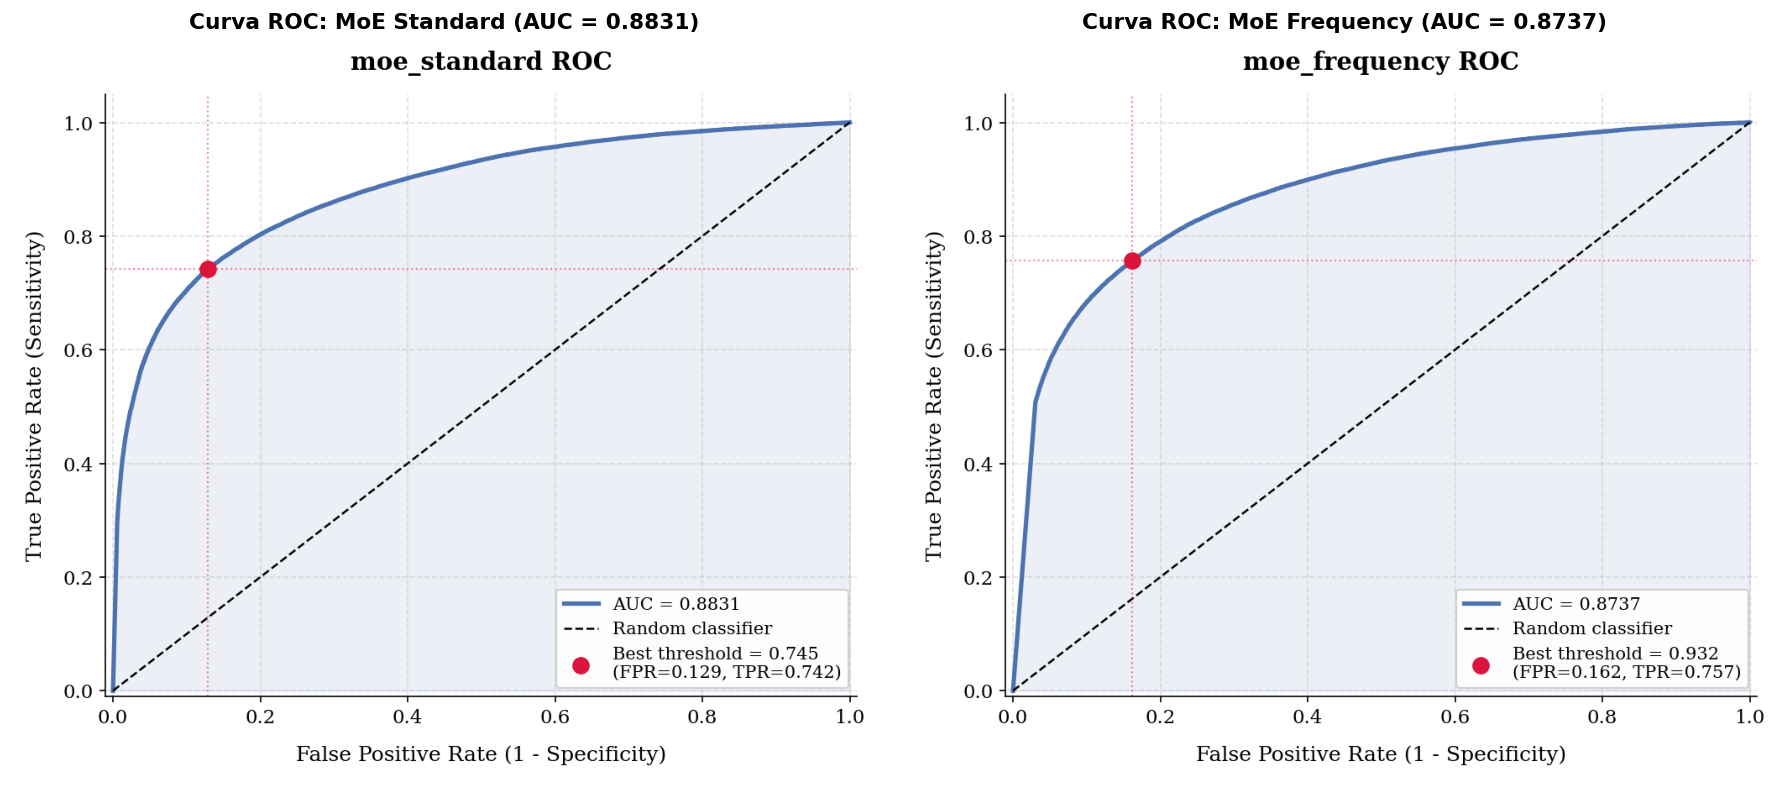

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
img_std_roc = plt.imread(std_data["dir"].parent / "plots" / "roc_auc.png")
img_freq_roc = plt.imread(freq_data["dir"].parent / "plots" / "roc_auc.png")

axes[0].imshow(img_std_roc)
axes[0].axis("off")
axes[0].set_title(f"Curva ROC: MoE Standard (AUC = {std_data['test']['auc'].iloc[0]:.4f})", fontweight="bold")

axes[1].imshow(img_freq_roc)
axes[1].axis("off")
axes[1].set_title(f"Curva ROC: MoE Frequency (AUC = {freq_data['test']['auc'].iloc[0]:.4f})", fontweight="bold")

plt.tight_layout()
plt.show()


## 7. Roteamento Dinâmico e a Nova Arquitetura Expandida (v2 - 7 Experts)

### Como os Especialistas Operam:
- **MoE Standard (4 Experts Homogêneos):**
  Todos os especialistas processam o mesmo tensor espacial $x \in \mathbb{R}^{3 	imes H 	imes W}$ (RGB), competindo em termos de representação convolucional.
- **MoE Frequency v1 (4 Experts por Domínio):**
  Desacopla os domínios:
  - `Expert 0`: Espacial RGB (3 canais)
  - `Expert 1`: FFT Magnitude (1 canal)
  - `Expert 2`: FFT Fase (1 canal)
  - `Expert 3`: FFT Passa-Alta (1 canal)

### 🚀 Atualização Arquitetural no Repositório (v2 - 7 Experts):
Com base nos resultados obtidos, a arquitetura em `src/models/moe.py` foi expandida para suportar **7 especialistas**:
1. **Expert 0 (3 ch):** Espacial RGB
2. **Expert 1 (1 ch):** FFT Log-Magnitude
3. **Expert 2 (1 ch):** FFT Fase
4. **Expert 3 (1 ch):** FFT Passa-Alta (High-Pass)
5. **Expert 4 (1 ch):** FFT Passa-Baixa (Low-Pass) *(Novo)*
6. **Expert 5 (4 ch):** Híbrido Espacial + Alta Frequência *(Novo)*
7. **Expert 6 (2 ch):** Híbrido Espectro Complexo (Magnitude + Fase) *(Novo)*

Esta versão permite ao roteador ponderar não apenas domínios isolados, mas combinações multi-escala diretas.


## 8. Conclusões e Síntese dos Resultados

1. **Maior Acurácia Global e F1-Score:** O **MoE Frequency** superou o Standard em acurácia de teste (**78.68% vs 77.88%**) e em F1-score (**79.69% vs 77.75%**).
2. **Redução Substancial de Falsos Negativos:** O modelo em frequência atingiu **72.92%** de Recall contra **67.39%** do padrão, detectando mais de **5.700 falsos positivos a menos** no cenário de ataque forense.
3. **Pico Superior na Validação:** Em validação, o MoE Frequency alcançou **0.9496** de ROC-AUC contra **0.9332** do MoE Standard.
4. **Eficiência Computacional no Treino:** O MoE Frequency atingiu seu ponto ótimo na Época 10 e utilizou o *Early Stopping* na época 18, economizando tempo frente às 20 épocas estritas do Standard.
